In [1]:
import pandas as pd
import matplotlib.pyplot as plt 


data = pd.read_csv("random_univariate_data.csv")


def loss_function(m, b, points):
    total_error = 0

    for i in range(len(points)):
        x = points.iloc[i].x
        y = points.iloc[i].y
        total_error += (y - (m * x + b)) ** 2
    return total_error / float(len(points))



In [2]:
def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x = points.iloc[i].x
        y = points.iloc[i].y

        m_gradient += -(2/n) * (y - (m_now*x + b_now)) * x
        b_gradient += -(2/n) * (y - (m_now*x + b_now))

    m = m_now - m_gradient*L
    b = b_now - b_gradient*L

    return m,b


In [3]:
m = 0
b = 0
L = 0.00025 
epochs = 25000 
m_values = []
b_values = []
loss_values = []

for i in range(epochs):
    m, b = gradient_descent(m, b, data, L)
    m_values.append(m)
    b_values.append(b)
    loss = loss_function(m, b, data)
    loss_values.append(loss)
    if i % 200 == 0: 
        print(f"Epoch: {i}, Loss: {loss:.4f}, m: {m:.4f}, b: {b:.4f}")

print(f"Final m: {m}")
print(f"Final b: {b}")




Epoch: 0, Loss: 629.0090, m: 0.9963, b: 0.0167
Epoch: 200, Loss: 64.3005, m: 0.5835, b: 0.3627
Epoch: 400, Loss: 61.9390, m: 0.5784, b: 0.7063
Epoch: 600, Loss: 59.6909, m: 0.5734, b: 1.0415
Epoch: 800, Loss: 57.5509, m: 0.5685, b: 1.3686
Epoch: 1000, Loss: 55.5137, m: 0.5638, b: 1.6877
Epoch: 1200, Loss: 53.5745, m: 0.5591, b: 1.9991
Epoch: 1400, Loss: 51.7284, m: 0.5546, b: 2.3029
Epoch: 1600, Loss: 49.9710, m: 0.5502, b: 2.5993
Epoch: 1800, Loss: 48.2980, m: 0.5458, b: 2.8885
Epoch: 2000, Loss: 46.7055, m: 0.5416, b: 3.1706
Epoch: 2200, Loss: 45.1895, m: 0.5375, b: 3.4459
Epoch: 2400, Loss: 43.7463, m: 0.5335, b: 3.7145
Epoch: 2600, Loss: 42.3725, m: 0.5296, b: 3.9766
Epoch: 2800, Loss: 41.0647, m: 0.5258, b: 4.2322
Epoch: 3000, Loss: 39.8197, m: 0.5221, b: 4.4817
Epoch: 3200, Loss: 38.6346, m: 0.5184, b: 4.7251
Epoch: 3400, Loss: 37.5064, m: 0.5149, b: 4.9626
Epoch: 3600, Loss: 36.4324, m: 0.5114, b: 5.1943
Epoch: 3800, Loss: 35.4100, m: 0.5081, b: 5.4204
Epoch: 4000, Loss: 34.4368

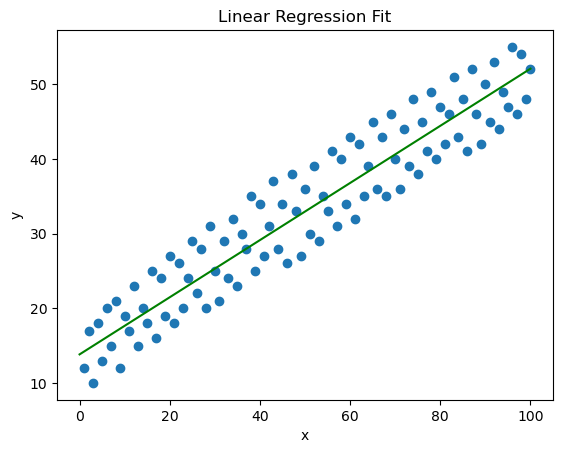

In [27]:
plt.scatter(data.x, data.y)
plt.plot([0,100], [b, m*100 + b], color='g') 
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


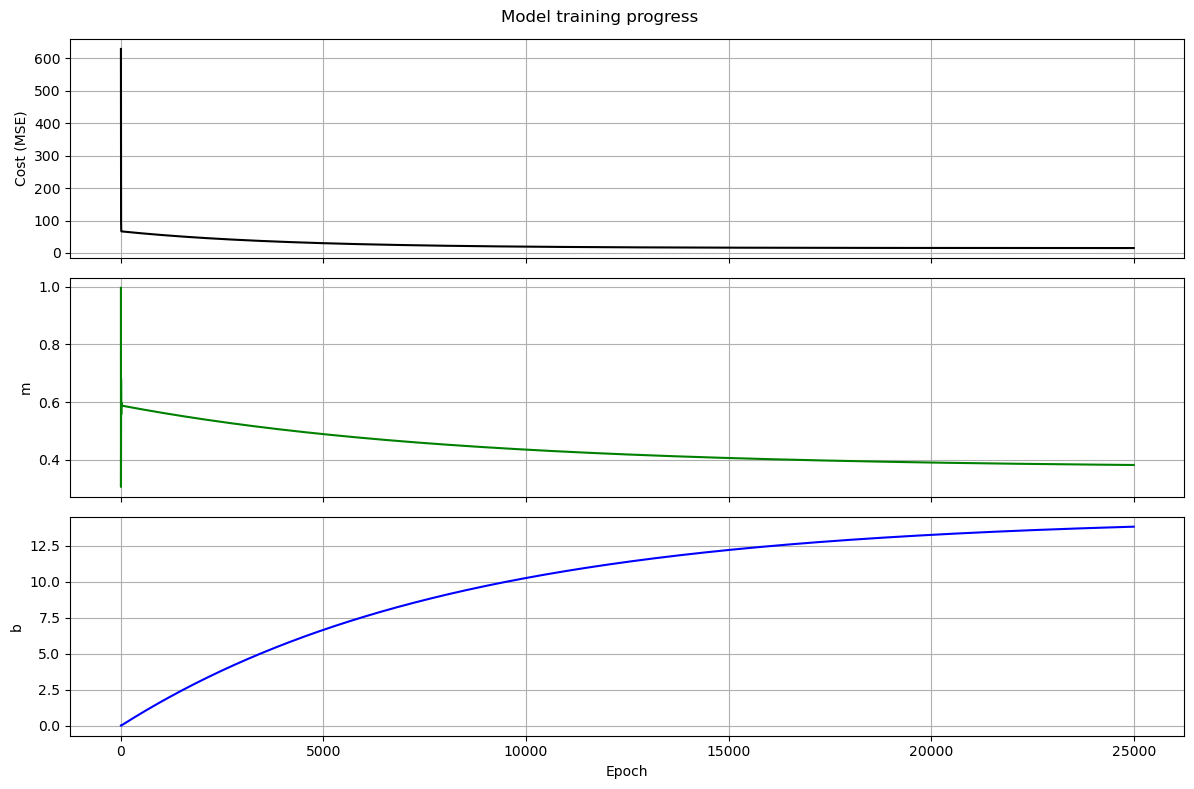

In [26]:

epoch_numbers_x = range(1, epochs + 1)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

fig.suptitle("Model training progress",)

axes[0].plot(epoch_numbers_x, loss_values, color='black')
axes[0].set_ylabel("Cost (MSE)")
axes[0].grid(True)

axes[1].plot(epoch_numbers_x, m_values, color='green')
axes[1].set_ylabel("m")
axes[1].grid(True)

axes[2].plot(epoch_numbers_x, b_values, color='blue')
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("b")
axes[2].grid(True)

plt.tight_layout()
plt.show()